<a href="https://colab.research.google.com/github/SathyaPrakashD/ml-pipeline-fundamentals/blob/main/09_ames_housing_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
url = 'https://raw.githubusercontent.com/austinlasseter/hosting_some_files/main/pandas_files/iowa.csv'
df = pd.read_csv(url)

print(df.shape)
print(df.dtypes.value_counts())
print(df.head())

(1460, 81)
object     43
int64      35
float64     3
Name: count, dtype: int64
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0 

### 1,460 houses, 81 columns.

This is exactly what we need:

Data type|Count|What it means
:---|:---|:---
object|43|Categorical columns → need OneHotEncoder
int64|35|Numeric columns → need StandardScaler
float64|3|Numeric columns → need StandardScaler


This is a real mixed dataset. 43 categorical columns and 38 numeric columns in the same DataFrame. ColumnTransformer is no longer a theoretical concept — it's a necessity here.

Also notice — you can already see NaN values in the first 5 rows (Alley, PoolQC, Fence). Missing values are a real challenge in this dataset. We'll need to handle those.

### Before EDA — two quick housekeeping steps:

In [32]:
# Drop Id column — it's just a row number, not a feature
df = df.drop(columns=['Id'])

# Check missing values
print(df.isnull().sum().sort_values(ascending=False).head(20))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageType        81
GarageFinish      81
GarageCond        81
GarageYrBlt       81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtFinType1      37
BsmtCond          37
MasVnrArea         8
Electrical         1
BldgType           0
dtype: int64


Interesting — Missing Values Tell a Story Here
Look at the top 4:
Column|Missing|What it likely means
:---|:---|:---
PoolQC|1453/1460|99.5% missing — almost no houses have a pool
MiscFeature|1406/1460|96% missing — rare miscellaneous features
Alley|1369/1460|93% missing — most houses have no alley access
Fence|1179/1460|80% missing — most houses have no fence


These aren't data quality problems — they're meaningful absences. "No pool" is valid information, not a data error.


Strategy — two types of missing values here:

Type|Examples|Fix
:---|:---|:---
Missing = "None/Not applicable"|PoolQC, Alley, Fence, FireplaceQu|Fill with "None" (categorical) or 0 (numeric)
Genuinely missing data|LotFrontage, MasVnrArea, Electrical|Fill with median (numeric) or mode (categorical)

###  Drop columns with more than 80% missing — too sparse to be useful

In [33]:
# Drop columns with more than 80% missing — too sparse to be useful
threshold = 0.8
df = df[df.columns[df.isnull().mean() < threshold]]

print(f"Columns remaining: {df.shape[1]}")
print(f"Missing values remaining:\n{df.isnull().sum().sort_values(ascending=False).head(10)}")

Columns remaining: 76
Missing values remaining:
MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageQual       81
GarageFinish     81
GarageType       81
GarageCond       81
GarageYrBlt      81
BsmtExposure     38
BsmtFinType2     38
dtype: int64


Down to 76 columns. But MasVnrType (872 missing) and FireplaceQu (690 missing) are still over 50% missing. Let's drop those too and then handle the rest inside the pipeline using imputation.

### Imputation — filling in missing values



In the real world, data is rarely complete. Rather than dropping entire rows because one value is missing, imputation fills in a reasonable substitute.

Analogy:
Imagine a school register where some students missed the height measurement day. You have two choices:

Remove those students entirely — lose all their other data
Fill in the average class height — keep them in the dataset with a reasonable estimate

**Imputation is option 2.**

Two most common strategies:
Strategy|When to use|Example
:---|:---|:---
Fill with median|Numeric columns — robust to outliers|Missing LotFrontage → fill with median lot frontage
Fill with most frequent value (mode)|Categorical columns — pick the most common category|Missing GarageType → fill with most common garage type

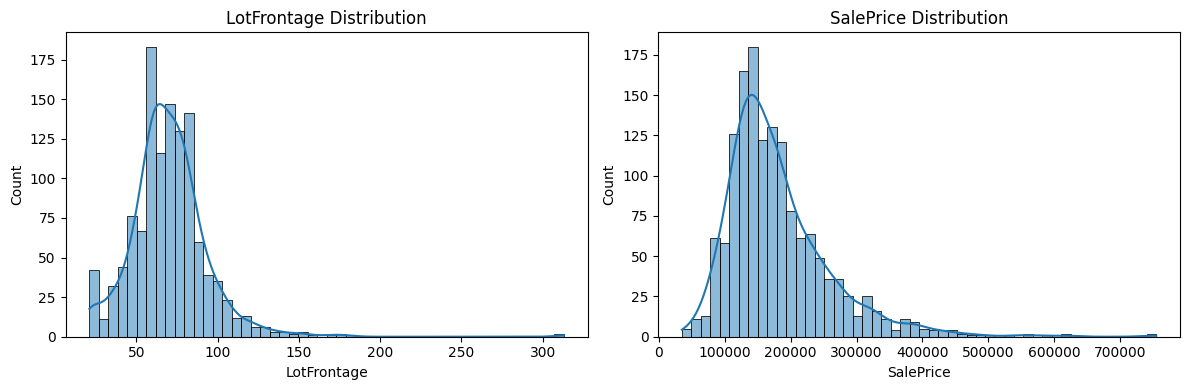

LotFrontage skew: 2.1636
SalePrice skew  : 1.8829


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# LotFrontage distribution
sns.histplot(df['LotFrontage'].dropna(), bins=50, kde=True, ax=axes[0])
axes[0].set_title('LotFrontage Distribution')

# SalePrice distribution
sns.histplot(df['SalePrice'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('SalePrice Distribution')

plt.tight_layout()
plt.show()

print(f"LotFrontage skew: {df['LotFrontage'].skew():.4f}")
print(f"SalePrice skew  : {df['SalePrice'].skew():.4f}")

Skew = 0 — perfectly symmetric. Mean = Median. Normal distribution.

Skew > 0 — right skewed. Tail on the right. Mean > Median.

Skew < 0 — left skewed. Tail on the left. Mean < Median.


What the magnitude tells you:

Skew value|Interpretation
:---|:---
0 to 0.5|Roughly symmetric — mild skew
0.5 to 1.0|Moderate skew — noticeable tail
1.0 to 2.0|High skew — significant tail, outliers present
Above 2.0|Extreme skew — heavy outliers, mean heavily distorted

So LotFrontage skew = 2.16 means:

Extreme right skew. A small number of very large properties are pulling the distribution heavily to the right. The mean is significantly higher than what a typical property actually has.

**The rule of thumb to lock:**

Skew above 1.0 — use median for imputation, use MAE as lead metric. Mean is distorted.

#### Skew Style

Distribution|Relationship
:---|:---
Right skew|Mean > Median
Left skew|Median > Mean
Normal|Mean ≈ Median

<br>

#### Imputation Strategy —

Distribution|Imputation strategy|Why
:---|:---|:---
Right skew|Median|Mean is inflated by outliers
Left skew|Median|Mean is deflated by outliers
Normal|Mean|No outliers distorting it — mean is reliable

<br>
The correction: Both right AND left skew → use Median. Any skew means outliers exist pulling the mean away from the typical value. Median is robust to outliers in both directions.

Mode is for categorical columns — not for normal distributions. Mode means "most frequent value" — that only makes sense for categories like "urban", "suburban", "rural", not for continuous numbers.

#### The clean rule:

Data type|Strategy
:---|:---
Numeric — skewed (either direction)|Median
Numeric — normal distribution|Mean
Categorical|Mode

In [35]:
print(f"Shape after cleaning: {df.shape}")
print(f"\nNumeric columns    : {df.select_dtypes(include=['int64','float64']).shape[1]}")
print(f"Categorical columns: {df.select_dtypes(include=['object']).shape[1]}")

Shape after cleaning: (1460, 76)

Numeric columns    : 37
Categorical columns: 39


In [36]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print(numeric_features)
print(categorical_features)

['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'Garag

### Build the full pipeline

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Step 1 — Separate features and target
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# Step 2 — Identify column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Step 3 — Build numeric pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Step 4 — Build categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Step 5 — Combine with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Step 6 — Full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Step 7 — Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8 — Train
pipeline.fit(X_train, y_train)

# Step 9 — Evaluate
y_pred = pipeline.predict(X_test)
print(f"MAE  : {mean_absolute_error(y_test, y_pred):,.0f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

MAE  : 17,526
RMSE : 28,744
R²   : 0.8923


#### Output

Metric|Value|Plain English
:---|:---|:---
MAE|$17,526|On average, predictions are off by $17,526
RMSE|$28,744|Large errors exist but contained
R²|0.8923|Model explains 89% of why house prices vary

89% R² on a real-world messy dataset with 39 categorical columns, missing values, and 76 features.

#### Feature Engineering

Let's engineer one meaningful feature for this dataset before the final prediction.
Looking at the columns — TotalBsmtSF (basement area) and GrLivArea (above ground living area) are both in the dataset.
What single engineered feature could you create from those two that might be more meaningful than either alone?

Total Living Area = GrLivArea + TotalBsmtSF

In [38]:
from sklearn.base import BaseEstimator, TransformerMixin

class TotalAreaTransformer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()
        X['TotalArea'] = X['GrLivArea'] + X['TotalBsmtSF']
        return X

#### Plug the Transformer into your pipeline and run it

In [40]:
# Add TotalArea to numeric features
numeric_features_updated = numeric_features + ['TotalArea']

# Rebuild preprocessor with updated numeric features
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features_updated),
    ('cat', categorical_pipeline, categorical_features)
])

# Full pipeline with CustomPreprocessor first
pipeline = Pipeline([
    ('feature_engineering', TotalAreaTransformer()),
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])


# Step 7 — Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8 — Train
pipeline.fit(X_train, y_train)

# Step 9 — Evaluate
y_pred = pipeline.predict(X_test)
print(f"MAE  : {mean_absolute_error(y_test, y_pred):,.0f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")


MAE  : 17,865
RMSE : 29,806
R²   : 0.8842


Interesting — metrics went slightly backwards:
Metric|Without TotalArea|With TotalArea|Change
:---|:---|:---|:---
MAE|$17,526|$17,865|❌ Worse
RMSE|$28,744|$29,806|❌ Worse
R²|0.8923|0.8842|❌ Worse



Why did this happen?
TotalArea = GrLivArea + TotalBsmtSF — but both of those columns already exist in the dataset. So the model now has:

GrLivArea — original ✅

TotalBsmtSF — original ✅

TotalArea — sum of both ✅


You've introduced multicollinearity — TotalArea is perfectly correlated with the two columns it was derived from. The model gets confused by the redundant signal.

####The fix — drop the original columns after engineering the combined one:

In [41]:
from sklearn.base import BaseEstimator, TransformerMixin

class TotalAreaTransformer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()
        X['TotalArea'] = X['GrLivArea'] + X['TotalBsmtSF']
        X = X.drop(columns=['GrLivArea', 'TotalBsmtSF'])
        return X

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Step 1 — Separate features and target
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# Step 2 — Identify column types (initial, before feature engineering)
numeric_features_initial = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Step 3 — Build numeric pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Step 4 — Build categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Step 6 — Full pipeline
pipeline = Pipeline([
    ('feature_engineering', TotalAreaTransformer()),
    # The preprocessor needs to be built with the feature names AFTER feature_engineering
    # We'll dynamically adjust the numeric_features list here
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', numeric_pipeline, [col for col in numeric_features_initial if col not in ['GrLivArea', 'TotalBsmtSF']] + ['TotalArea']),
        ('cat', categorical_pipeline, categorical_features)
    ])),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Step 7 — Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8 — Train
pipeline.fit(X_train, y_train)

# Step 9 — Evaluate
y_pred = pipeline.predict(X_test)
print(f"MAE  : {mean_absolute_error(y_test, y_pred):,.0f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

MAE  : 17,801
RMSE : 29,749
R²   : 0.8846


In [44]:
# Correlation of all numeric features with SalePrice only
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlation_with_target = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
print(correlation_with_target.head(15))
print(correlation_with_target.tail(5))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


<Axes: >

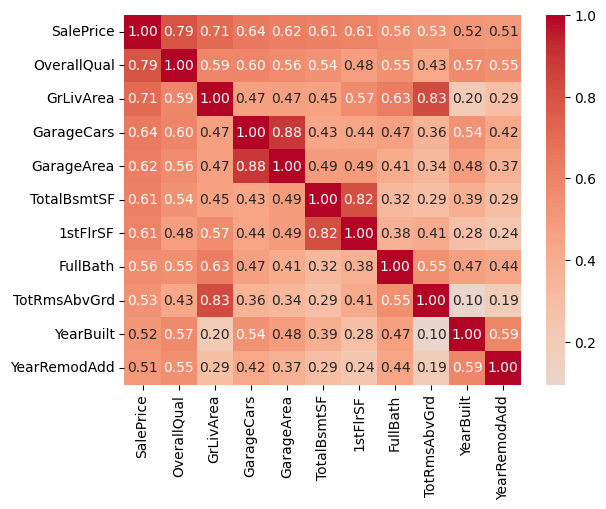

In [45]:
top_features = correlation_with_target.head(11).index.tolist()  # top 10 + SalePrice
sns.heatmap(numeric_df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)

#### On SalePrice correlations:

OverallQual = 0.79 — strongest signal. Makes intuitive sense — overall quality directly drives price.
GrLivArea = 0.71 — second strongest. Bigger house = higher price. Also intuitive.


On GarageCars ↔ GarageArea = 0.88 — multicollinearity confirmed.
Exactly right. Bigger garage area = more cars it fits. They're saying the same thing twice. One should be dropped.

#### Now validate your feature engineering decision:
Look at the correlation values:

GrLivArea → SalePrice = 0.71
TotalBsmtSF → SalePrice = 0.61

Both individually have strong correlations with SalePrice. When you combined them into TotalArea and dropped the originals — you lost those two independent signals and replaced them with one. The model lost information.
This is why your metrics got worse — now confirmed with evidence from the heatmap.

The complete validation chain ✅
Decision|Evidence
:---|:---
Keep GrLivArea and TotalBsmtSF separate|Both have strong individual correlations with SalePrice
Drop TotalArea engineered feature|Combining them lost information — metrics confirmed it
Drop one of GarageCars/GarageArea|Multicollinearity = 0.88
MAE as lead metric|SalePrice skew = 1.88

In [49]:
from sklearn.base import BaseEstimator, TransformerMixin

class MulticollinearityTransformer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()
        #X['TotalArea'] = X['GrLivArea'] + X['TotalBsmtSF']
        X = X.drop(columns=['GarageCars', 'GarageArea'])
        return X

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Step 1 — Separate features and target
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# Step 2 — Identify column types (initial, before feature engineering)
numeric_features_initial = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Step 3 — Build numeric pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Step 4 — Build categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Step 6 — Full pipeline
pipeline = Pipeline([
    ('feature_engineering', MulticollinearityTransformer()),
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', numeric_pipeline,
         [col for col in numeric_features_initial if col not in ['GarageCars','GarageArea']]),
        ('cat', categorical_pipeline, categorical_features)
    ])),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Step 7 — Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8 — Train
pipeline.fit(X_train, y_train)

# Step 9 — Evaluate
y_pred = pipeline.predict(X_test)
print(f"MAE  : {mean_absolute_error(y_test, y_pred):,.0f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

MAE  : 18,065
RMSE : 28,889
R²   : 0.8912


Metric|Baseline|After dropping GarageCars|Change
:---|:---|:---|:---
MAE|$17,526|$18,065|❌ Worse
RMSE|$28,744|$28,889|❌ Worse
R²|0.8923|0.8912|❌ Worse

Same lesson as TotalArea — confirmed again.
Random Forest handles multicollinearity naturally. Unlike Linear Regression, it doesn't get confused by correlated features — it simply learns which one is more useful and uses that one more. Dropping GarageCars removed signal the model was already managing well.

The honest conclusion for Round 8:

For Random Forest, the baseline pipeline without feature engineering or manual multicollinearity removal is the strongest model. Random Forest doesn't need your help managing correlated features — it handles it internally.

Feature engineering and multicollinearity removal matter more for Linear Regression — where correlated features genuinely break the model.

Your baseline remains the winner:
Model|MAE|R²
:---|:---|:---
Baseline Random Forest|$17,526|0.8923
+ TotalArea|$17,801|0.8846
+ Drop GarageCars|$18,065|0.8912